In [1]:
!pip install numpy pandas matplotlib scikit-learn opencv-python --quiet

# Лабораторная 8

# ______________________________________________________________________

#### Подключение библиотек

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.metrics import mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

#### Задание 1

In [3]:
mu = 124.5
num_iter = 1000
t = np.arange(num_iter)
x_true = mu * np.ones(num_iter)
R_est = 0.1
measurements = x_true + np.random.normal(0, np.sqrt(R_est), num_iter)

Для каждой итерации генерируем измерение с шумом R_est=0.1 вокруг истинного значения 124.5. Фильтр Калмана должен оценить истинное значение.

In [4]:
def kalman_1d(x, P, measurement, R_est, Q_est):
    x_pred = x
    P_pred = P + Q_est

    K = P_pred / (P_pred + R_est)
    x = x_pred + K * (measurement - x_pred)
    P = (1 - K) * P_pred

    return x, P

In [5]:
Q_base = 1e-4
x_est, P = 0.0, 0.5
estimates = []

for z in measurements:
    x_est, P = kalman_1d(x_est, P, z, R_est, Q_base)
    estimates.append(x_est)

print(f"Истинное: {mu:.4f}, Оценка: {x_est:.4f}")
print(f"Среднее измерений: {np.mean(measurements):.4f}")

Истинное: 124.5000, Оценка: 124.4902
Среднее измерений: 124.5061


При малом Q_est фильтр доверяет модели больше, чем измерениям. Оценка составила 124.4902 — практически совпадает с истинным значением 124.5, что подтверждает эффективность фильтра при малом шуме модели.

In [6]:
Q_mod = 1.0
x_est2, P2 = 0.0, 0.5
estimates2 = []

for z in measurements:
    x_est2, P2 = kalman_1d(x_est2, P2, z, R_est, Q_mod)
    estimates2.append(x_est2)

print(f"Истинное: {mu:.4f}, Оценка (Q=1.0): {x_est2:.4f}")

Истинное: 124.5000, Оценка (Q=1.0): 124.6536


При Q_est = 1.0 оценка (124.6536) отклоняется от истинного значения 124.5 сильнее, чем при малом Q. Большое Q_est заставляет фильтр больше доверять шумным измерениям, что снижает точность.

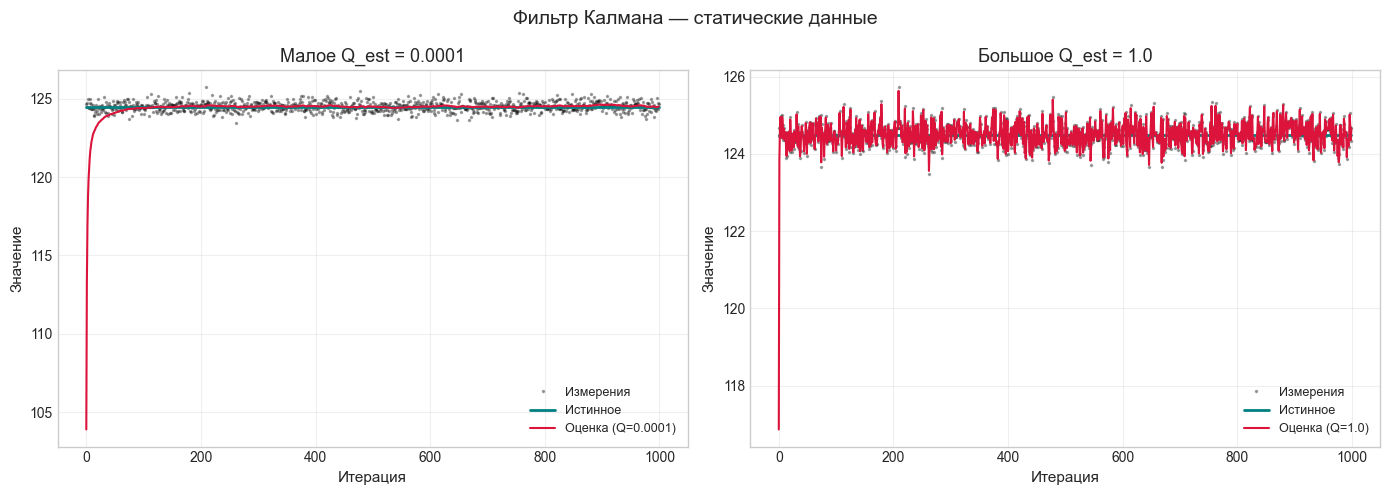

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, measurements, "k.", alpha=0.3, markersize=3, label="Измерения")
axes[0].plot(t, x_true, "teal", lw=2, label="Истинное")
axes[0].plot(t, estimates, "crimson", lw=1.5, label=f"Оценка (Q={Q_base})")
axes[0].set_title(f"Малое Q_est = {Q_base}", fontsize=13)
axes[0].set_xlabel("Итерация", fontsize=11)
axes[0].set_ylabel("Значение", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, measurements, "k.", alpha=0.3, markersize=3, label="Измерения")
axes[1].plot(t, x_true, "teal", lw=2, label="Истинное")
axes[1].plot(t, estimates2, "crimson", lw=1.5, label=f"Оценка (Q={Q_mod})")
axes[1].set_title(f"Большое Q_est = {Q_mod}", fontsize=13)
axes[1].set_xlabel("Итерация", fontsize=11)
axes[1].set_ylabel("Значение", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Фильтр Калмана — статические данные", fontsize=14)
plt.tight_layout()
plt.show()

При Q_est = 1.0 оценка быстрее сходится к измерениям. Q_est определяет доверие к модели vs измерениям. Большое Q_est фильтр следует за измерениями.

### Задание 2

In [8]:
v0 = 0.3
dt = 1.0
num_iter = 100
t = np.arange(num_iter)
x_true = v0 * t
R_est = 0.5
measurements = x_true + np.random.normal(0, np.sqrt(R_est), num_iter)

A = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[1e-4, 0], [0, 1e-4]])
R = np.array([[R_est]])

Модель с постоянной скоростью. Состояние: [позиция, скорость]. Измеряется только позиция.

In [9]:
x = np.array([[0], [0.3]])
P = np.array([[0.5, 0], [0, 0.5]])
est_pos, est_vel = [], []
P_history = []

for z in measurements:
    x = A @ x
    P = A @ P @ A.T + Q

    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
    x = x + K @ (z - H @ x)
    P = (np.eye(2) - K @ H) @ P

    est_pos.append(x[0, 0])
    est_vel.append(x[1, 0])
    P_history.append(P.copy())

est_pos = np.array(est_pos)
est_vel = np.array(est_vel)

Оценка позиции (синяя) следует за измерениями (чёрные точки) и истинной траекторией (зелёная). Оценка скорости стабилизируется около 0.3.

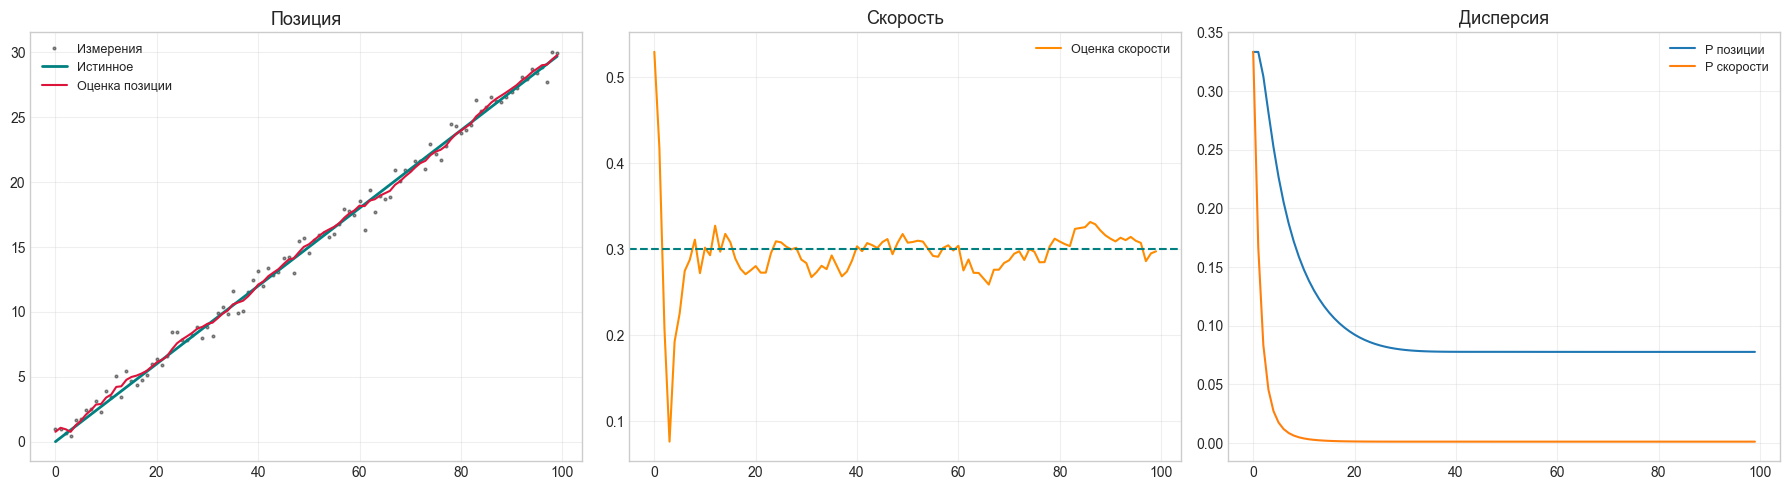

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Позиция ---
axes[0].plot(t, measurements, "k.", alpha=0.4, markersize=4, label="Измерения")
axes[0].plot(t, x_true, "teal", lw=2, label="Истинное")
axes[0].plot(t, est_pos, "crimson", lw=1.5, label="Оценка позиции")
axes[0].set_title("Позиция", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Скорость ---
axes[1].plot(t, est_vel, "darkorange", lw=1.5, label="Оценка скорости")
axes[1].axhline(y=v0, color="teal", linestyle="--")
axes[1].set_title("Скорость", fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Дисперсия ---
P_arr = np.array(P_history)
if P_arr.ndim != 3:
    raise ValueError("P_history не заполнен корректно. Добавь P_history.append(P.copy()) в цикл.")
P_pos = P_arr[:, 0, 0]
P_vel = P_arr[:, 1, 1]

axes[2].plot(t, P_pos, lw=1.5, label="P позиции")
axes[2].plot(t, P_vel, lw=1.5, label="P скорости")
axes[2].set_title("Дисперсия", fontsize=13)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

P позиции быстро уменьшается — фильтр уверен в оценке позиции. P скорости остаётся выше — неопределённость скорости больше.

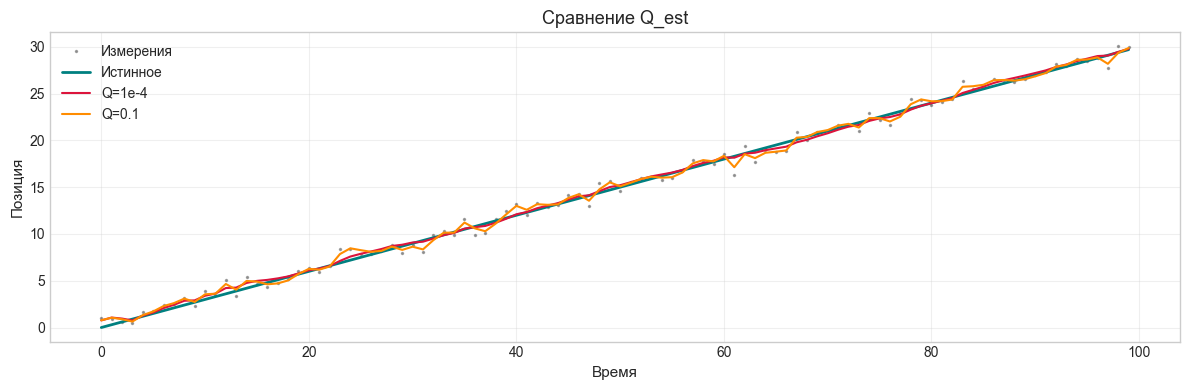

In [11]:
x2 = np.array([[0], [0.3]])
P2 = np.array([[0.5, 0], [0, 0.5]])
Q2 = np.array([[0.1, 0], [0, 0.1]])
est_pos2 = []

for z in measurements:
    x2 = A @ x2
    P2 = A @ P2 @ A.T + Q2
    K = P2 @ H.T @ np.linalg.inv(H @ P2 @ H.T + R)
    x2 = x2 + K @ (z - H @ x2)
    P2 = (np.eye(2) - K @ H) @ P2
    est_pos2.append(x2[0, 0])

est_pos2 = np.array(est_pos2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, measurements, "k.", alpha=0.3, markersize=3, label="Измерения")
ax.plot(t, x_true, "teal", lw=2, label="Истинное")
ax.plot(t, est_pos, "crimson", lw=1.5, label="Q=1e-4")
ax.plot(t, est_pos2, "darkorange", lw=1.5, label="Q=0.1")
ax.set_title("Сравнение Q_est", fontsize=13)
ax.set_xlabel("Время", fontsize=11)
ax.set_ylabel("Позиция", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

На графике видно: при Q=1e-4 оценка следует за истинным значением плавно и слабо реагирует на выбросы измерений. При Q=0.1 оценка заметно колеблется вместе с измерениями. Q_est определяет компромисс между гладкостью и скоростью реакции.

## Задание 3

In [12]:
xy_data = pd.read_csv(
    "xy_motion.csv",
    header=0, names=["frame", "x", "y"], engine="python"
)
xy_true = xy_data[["x", "y"]].values
n_obs = len(xy_true)

R_2d = np.array([[1.0, 0], [0, 1.0]])
Q_2d = np.eye(4) * 1e-4

measurements_2d = xy_true + np.random.multivariate_normal([0, 0], R_2d, n_obs)

print(f"Наблюдений: {n_obs}")
print(f"Форма данных: {xy_true.shape}")

Наблюдений: 200
Форма данных: (200, 2)


Датасет содержит 200 кадров с 2D координатами. Добавляем шум с дисперсией 1.0 для моделирования измерений.

In [13]:
kf_cv = cv2.KalmanFilter(4, 2, 0)
kf_cv.transitionMatrix = np.array([[1, 0, 1, 0],
                                     [0, 1, 0, 1],
                                     [0, 0, 1, 0],
                                     [0, 0, 0, 1]], dtype=np.float32)
kf_cv.measurementMatrix = np.array([[1, 0, 0, 0],
                                      [0, 1, 0, 0]], dtype=np.float32)
kf_cv.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-4
kf_cv.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1.0
kf_cv.errorCovPost = np.eye(4, dtype=np.float32) * 0.5

kf_cv.statePost = np.array([[xy_true[0, 0]], [xy_true[0, 1]], [0], [0]], dtype=np.float32)

est_cv = []
for z in measurements_2d:
    kf_cv.predict()
    z_arr = np.array([[z[0]], [z[1]]], dtype=np.float32)
    corrected = kf_cv.correct(z_arr)
    est_cv.append([corrected[0, 0], corrected[1, 0]])

est_cv = np.array(est_cv)
print(f"Форма оценки CV: {est_cv.shape}")

Форма оценки CV: (200, 2)


Модель постоянной скорости (CV): состояние 4x2, измеряются только координаты x и y.

Модель постоянного ускорения (CA)

In [14]:
dt = 1.0
kf_ca = cv2.KalmanFilter(6, 2, 0)
A_ca = np.array([[1, 0, dt, 0, 0.5*dt**2, 0],
                  [0, 1, 0, dt, 0, 0.5*dt**2],
                  [0, 0, 1, 0, dt, 0],
                  [0, 0, 0, 1, 0, dt],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1]], dtype=np.float32)
kf_ca.transitionMatrix = A_ca
kf_ca.measurementMatrix = np.array([[1, 0, 0, 0, 0, 0],
                                      [0, 1, 0, 0, 0, 0]], dtype=np.float32)
kf_ca.processNoiseCov = np.eye(6, dtype=np.float32) * 1e-4
kf_ca.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1.0
kf_ca.errorCovPost = np.eye(6, dtype=np.float32) * 0.5

kf_ca.statePost = np.array([[xy_true[0, 0]], [xy_true[0, 1]], [0], [0], [0], [0]], dtype=np.float32)

est_ca = []
for z in measurements_2d:
    kf_ca.predict()
    z_arr = np.array([[z[0]], [z[1]]], dtype=np.float32)
    corrected = kf_ca.correct(z_arr)
    est_ca.append([corrected[0, 0], corrected[1, 0]])

est_ca = np.array(est_ca)
print(f"Форма оценки CA: {est_ca.shape}")

Форма оценки CA: (200, 2)


Модель постоянного ускорения (CA): состояние 6x1, включает позицию, скорость и ускорение.

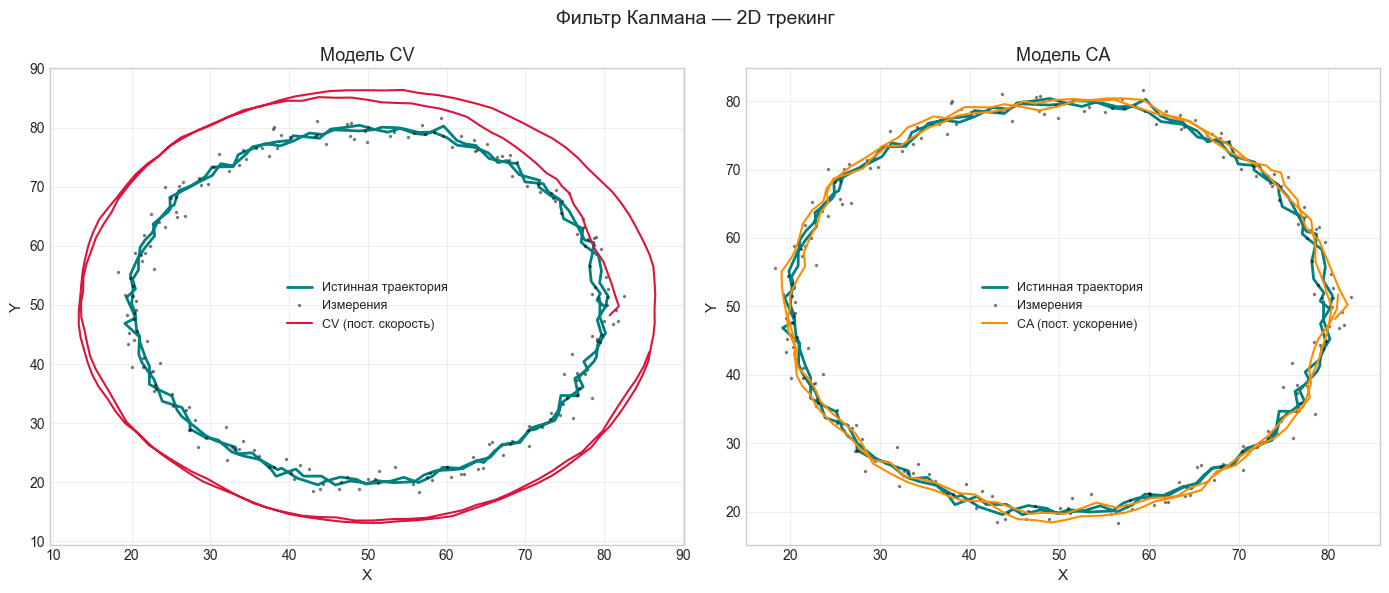

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(xy_true[:, 0], xy_true[:, 1], "teal", lw=2, label="Истинная траектория")
axes[0].plot(measurements_2d[:, 0], measurements_2d[:, 1], "k.", alpha=0.4, markersize=3, label="Измерения")
axes[0].plot(est_cv[:, 0], est_cv[:, 1], "crimson", lw=1.5, label="CV (пост. скорость)")
axes[0].set_title("Модель CV", fontsize=13)
axes[0].set_xlabel("X", fontsize=11)
axes[0].set_ylabel("Y", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(xy_true[:, 0], xy_true[:, 1], "teal", lw=2, label="Истинная траектория")
axes[1].plot(measurements_2d[:, 0], measurements_2d[:, 1], "k.", alpha=0.4, markersize=3, label="Измерения")
axes[1].plot(est_ca[:, 0], est_ca[:, 1], "darkorange", lw=1.5, label="CA (пост. ускорение)")
axes[1].set_title("Модель CA", fontsize=13)
axes[1].set_xlabel("X", fontsize=11)
axes[1].set_ylabel("Y", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Фильтр Калмана — 2D трекинг", fontsize=14)
plt.tight_layout()
plt.show()

Сравнение MSE

In [16]:
mse_cv = mean_squared_error(xy_true, est_cv)
mse_ca = mean_squared_error(xy_true, est_ca)

print(f"MSE CV: {mse_cv:.4f}")
print(f"MSE CA: {mse_ca:.4f}")
print(f"CA лучше в {mse_cv/mse_ca:.1f} раз" if mse_ca < mse_cv else f"CV лучше в {mse_ca/mse_cv:.1f} раз")

MSE CV: 44.5461
MSE CA: 0.6574
CA лучше в 67.8 раз


CV модель даёт MSE = 44.55, CA - 0.66. Модель постоянного ускорения (CA) лучше в 67.8 раз для данного набора данных. CA лучше подходит, когда траектория содержит участки с ускорениями и нелинейными изменениями.